# JSON 기반 이미지 분류/검출 EDA

폴더 안의 **COCO-유사 JSON** 파일들을 재귀적으로 읽어서,

- `images / annotations / categories`를 합쳐 **이미지 단위 레코드** 생성
- 분류 관점 라벨(기본: `annotations.category_id`) + 품목/shape 기반 EDA 추가
- bbox **존재/유효 기준**에 따라 유효 객체만 집계
- 결과를 `CSV`로 저장해 재사용 가능하게 구성

---

## 데이터 정의(요약)
- `image_id`: 파일명 기준으로 고유하게 부여됨(제공 데이터 설명)
- `category_id`: 각 JSON 내 첫 번째 이미지의 `dl_idx`를 정수형으로 할당됨(제공 데이터 설명)
- `annotation_id`: bbox가 **존재**하고 **유효**한 annotation에 대해 순차적으로 부여됨(제공 데이터 설명)

### bbox 존재/유효 기준
- 존재: annotation에 `"bbox"` 키가 있고 값이 비어있지 않음
- 유효: bbox가 list이고 길이가 정확히 4 ([x, y, w, h])


## EDA 진행 순서(정리)

1. **데이터 로딩/파싱**: JSON → `df`(이미지 단위) / `obj_df`(객체 단위) 생성  
2. **품질 진단(QC)**: 결측/유니크/annotation 유효성/ bbox 품질(음수/0면적/경계초과)  
3. **핵심 분포 EDA(학습 직결)**  
   - 클래스(라벨) 분포: 이미지 기준 + 객체 기준  
   - 객체 수 분포: 이미지당 유효 bbox 개수  
   - bbox 스케일(상대면적) / 종횡비 분포  
4. **요인 분석 EDA(편향 확인)**  
   - shape(모양), item_seq(품목), 촬영조건(back_color/light_color/drug_dir) 등  
5. **모든 라벨 자동 EDA(확장)**  
   - 이미 앞에서 다룬 컬럼은 **자동 EDA에서 제외**하여 중복을 줄임  
6. **라벨 정리표(Q1 적용)**: 검출 클래스 후보 vs 보조/메타 컬럼 구분 + 매핑 충돌 체크  
7. **학습 전략 리포트(Q3 적용)**: EDA 지표 기반으로 “예상 난이도/권장 설정” 자동 요약.


In [27]:
# =========================
# 0) 라이브러리 & (선택) 폰트 설정
# =========================
import os, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [28]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ---- (PATCH) Matplotlib 한글 폰트/마이너스 깨짐 ----
def _set_korean_font():
    candidates = []
    if os.name == "nt":  # Windows
        candidates = ["Malgun Gothic"]
    else:
        candidates = ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans"]
    try:
        from matplotlib import font_manager
        installed = {f.name for f in font_manager.fontManager.ttflist}
        for name in candidates:
            if name in installed:
                mpl.rcParams["font.family"] = name
                break
    except Exception:
        pass
    mpl.rcParams["axes.unicode_minus"] = False

_set_korean_font()
print("matplotlib font:", mpl.rcParams.get("font.family"))


matplotlib font: ['Malgun Gothic']


In [29]:
# =========================
# 1) 경로 설정
# =========================
ANN_ROOT = Path("./data/train_annotations")  # JSON 루트
IMG_ROOT = Path("./data/train_images")
JSON_GLOB = "**/*.json"  # 필요 시 Path("./data/train_images") 등으로 지정
JSON_GLOB = "**/*.json"

print("ANN_ROOT:", ANN_ROOT.resolve())
print("IMG_ROOT:", IMG_ROOT.resolve() if isinstance(IMG_ROOT, Path) else IMG_ROOT)


ANN_ROOT: C:\Users\TAEHO\Desktop\AI_07_basic\data\train_annotations
IMG_ROOT: C:\Users\TAEHO\Desktop\AI_07_basic\data\train_images


In [30]:
# =========================
# 2) 파서: JSON 1개 → 이미지 단위 레코드
#    - bbox 존재/유효 기준 반영
# =========================
from typing import Any, Dict, List, Optional, Tuple

def bbox_exists(a: dict) -> bool:
    return ("bbox" in a) and (a.get("bbox") is not None) and (a.get("bbox") != [])

def bbox_is_valid(a: dict) -> bool:
    bb = a.get("bbox")
    return isinstance(bb, list) and (len(bb) == 4)

def parse_one_json(json_path: Path) -> List[Dict[str, Any]]:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    images = data.get("images", []) or []
    annots = data.get("annotations", []) or []
    cats   = data.get("categories", []) or []

    # category_id -> name
    catid2name = {c.get("id"): c.get("name") for c in cats if isinstance(c, dict)}

    # image_id -> annots (전체)
    imgid2ann_all = {}
    for a in annots:
        if not isinstance(a, dict):
            continue
        img_id = a.get("image_id")
        imgid2ann_all.setdefault(img_id, []).append(a)

    rows = []
    for img in images:
        if not isinstance(img, dict):
            continue

        image_id = img.get("id")
        img_anns_all = imgid2ann_all.get(image_id, [])

        # 존재/유효 bbox 기준으로 필터링(객체 통계용)
        img_anns_exist = [a for a in img_anns_all if bbox_exists(a)]
        img_anns_valid = [a for a in img_anns_exist if bbox_is_valid(a)]

        # 분류 라벨(기본): valid annotation의 category_id set
        # (없으면 categories 첫 항목 fallback)
        if len(img_anns_valid) > 0:
            cat_ids = sorted({a.get("category_id") for a in img_anns_valid})
        else:
            fallback = cats[0] if isinstance(cats, list) and len(cats) else {}
            cat_ids = [fallback.get("id")] if isinstance(fallback, dict) else [None]

        cat_names = [catid2name.get(cid) for cid in cat_ids]

        # bbox list (valid만)
        bboxes = [a.get("bbox") for a in img_anns_valid]

        row = {
            "json_path": str(json_path),
            "file_name": img.get("file_name") or img.get("imgfile"),
            "width": img.get("width"),
            "height": img.get("height"),
            "image_id": image_id,

            # ---- 품목/메타 ----
            "drug_N": img.get("drug_N"),
            "drug_S": img.get("drug_S"),
            "item_seq": img.get("item_seq"),              # 품목기준코드
            "dl_idx": img.get("dl_idx"),                  # 알약 식별자(문자열일 수 있음)
            "dl_mapping_code": img.get("dl_mapping_code"),
            "dl_name": img.get("dl_name"),
            "dl_company": img.get("dl_company"),
            "dl_material": img.get("dl_material"),
            "di_class_no": img.get("di_class_no"),
            "di_etc_otc_code": img.get("di_etc_otc_code"),
            "back_color": img.get("back_color"),
            "drug_dir": img.get("drug_dir"),
            "light_color": img.get("light_color"),
            "camera_la": img.get("camera_la"),
            "camera_lo": img.get("camera_lo"),
            "size": img.get("size"),

            # ---- shape 관련 ----
            "drug_shape": img.get("drug_shape"),          # 알약 모양(라벨 수준)
            "dl_custom_shape": img.get("dl_custom_shape"),# 제조 모양
            "form_code_name": img.get("form_code_name"),  # 정제 분류명
            "color_class1": img.get("color_class1"),
            "color_class2": img.get("color_class2"),
            "print_front": img.get("print_front"),
            "print_back": img.get("print_back"),
            "line_front": img.get("line_front"),
            "line_back": img.get("line_back"),

            # ---- 라벨/객체 ----
            "label_cids": cat_ids,
            "label_names": cat_names,

            # 객체/annotation 상태 카운트
            "n_ann_total": len(img_anns_all),
            "n_ann_bbox_exists": len(img_anns_exist),
            "n_ann_bbox_valid": len(img_anns_valid),

            # valid bbox만 저장
            "bboxes": bboxes,
        }
        rows.append(row)

    return rows


In [31]:
# =========================
# 3) 전체 JSON 로딩
# =========================
json_paths = sorted(ANN_ROOT.glob(JSON_GLOB))
print(f"Found {len(json_paths)} json files")

all_rows = []
bad_files = []

for p in json_paths:
    try:
        all_rows.extend(parse_one_json(p))
    except Exception as e:
        bad_files.append((str(p), repr(e)))

df = pd.DataFrame(all_rows)
print("rows:", len(df))
print("bad_files:", len(bad_files))

if bad_files:
    display(pd.DataFrame(bad_files, columns=["path","error"]).head(20))

df.head()


Found 763 json files
rows: 763
bad_files: 0


,json_path,file_name,width,height,image_id,drug_N,drug_S,item_seq,dl_idx,dl_mapping_code,dl_name,dl_company,dl_material,di_class_no,di_etc_otc_code,back_color,drug_dir,light_color,camera_la,camera_lo,size,drug_shape,dl_custom_shape,form_code_name,color_class1,color_class2,print_front,print_back,line_front,line_back,label_cids,label_names,n_ann_total,n_ann_bbox_exists,n_ann_bbox_valid,bboxes
0,data\train_annotations\K-001900-016548-019607-...,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,34,K-001900,정상알약,198700706,1900,K-001900,보령부스파정 5mg,보령제약(주),부스피론염산염,[01170]정신신경용제,전문의약품,연회색 배경,앞면,주백색,70,0,200,장방형,"정제, 저작정",나정,하양,,BSP,5,,,[1900],[보령부스파정 5mg],1,1,1,"[[644, 845, 189, 190]]"
1,data\train_annotations\K-001900-016548-019607-...,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,35,K-001900,정상알약,198700706,1900,K-001900,보령부스파정 5mg,보령제약(주),부스피론염산염,[01170]정신신경용제,전문의약품,연회색 배경,앞면,주백색,75,0,200,장방형,"정제, 저작정",나정,하양,,BSP,5,,,[1900],[보령부스파정 5mg],1,1,1,"[[148, 241, 181, 181]]"
2,data\train_annotations\K-001900-016548-019607-...,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,36,K-001900,정상알약,198700706,1900,K-001900,보령부스파정 5mg,보령제약(주),부스피론염산염,[01170]정신신경용제,전문의약품,연회색 배경,앞면,주백색,90,0,200,장방형,"정제, 저작정",나정,하양,,BSP,5,,,[1900],[보령부스파정 5mg],1,1,1,"[[167, 248, 184, 182]]"
3,data\train_annotations\K-001900-016548-019607-...,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,34,K-016548,정상알약,200500251,16548,K-016548,가바토파정 100mg,동아에스티(주),토피라메이트,[01130]항전간제,전문의약품,연회색 배경,앞면,주백색,70,0,200,None,"정제, 저작정",None,None,None,None,None,None,None,[16548],[가바토파정 100mg],1,1,1,"[[144, 799, 239, 239]]"
4,data\train_annotations\K-001900-016548-019607-...,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,35,K-016548,정상알약,200500251,16548,K-016548,가바토파정 100mg,동아에스티(주),토피라메이트,[01130]항전간제,전문의약품,연회색 배경,앞면,주백색,75,0,200,None,"정제, 저작정",None,None,None,None,None,None,None,[16548],[가바토파정 100mg],1,1,1,"[[578, 222, 233, 226]]"


In [32]:
# =========================
# 4) 분류용 단일 라벨(대표 라벨) 만들기
# =========================
def pick_primary_label(cids, names):
    cid = cids[0] if isinstance(cids, list) and len(cids) else None
    name = names[0] if isinstance(names, list) and len(names) else None
    return cid, name

df[["label_cid","label_name"]] = df.apply(
    lambda r: pd.Series(pick_primary_label(r["label_cids"], r["label_names"])),
    axis=1
)

df["is_multilabel"] = df["label_cids"].apply(lambda x: isinstance(x, list) and len(set(x)) > 1)
df[["file_name","image_id","label_cid","label_name","n_ann_bbox_valid","is_multilabel"]].head()


,file_name,image_id,label_cid,label_name,n_ann_bbox_valid,is_multilabel
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,1900,보령부스파정 5mg,1,False
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,1900,보령부스파정 5mg,1,False
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,1900,보령부스파정 5mg,1,False
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,16548,가바토파정 100mg,1,False
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,16548,가바토파정 100mg,1,False


## 5) 데이터 품질 체크 (필수/주요 컬럼 결측 + bbox 존재/유효)

In [33]:
# 주요 컬럼 결측치/유니크 요약
cols = [
    "file_name","image_id","width","height",
    "drug_N","drug_S","item_seq","dl_idx","dl_name","dl_company",
    "drug_shape","dl_custom_shape","form_code_name",
    "label_cid","label_name",
    "n_ann_total","n_ann_bbox_exists","n_ann_bbox_valid"
]

summary = []
for col in cols:
    summary.append({
        "col": col,
        "n_null": int(df[col].isna().sum()),
        "n_unique": int(df[col].nunique(dropna=True)),
    })

display(pd.DataFrame(summary).sort_values("n_null", ascending=False))


,col,n_null,n_unique
10,drug_shape,18,5
12,form_code_name,18,7
1,image_id,0,232
0,file_name,0,232
2,width,0,1
3,height,0,1
6,item_seq,0,56
7,dl_idx,0,56
4,drug_N,0,56
5,drug_S,0,1


In [34]:
# bbox 존재/유효 비율 확인
tmp = pd.DataFrame({
    "total_images": [len(df)],
    "images_with_any_ann": [(df["n_ann_total"] > 0).sum()],
    "images_with_bbox_exists": [(df["n_ann_bbox_exists"] > 0).sum()],
    "images_with_bbox_valid": [(df["n_ann_bbox_valid"] > 0).sum()],
})
tmp["pct_bbox_exists"] = tmp["images_with_bbox_exists"] / tmp["total_images"]
tmp["pct_bbox_valid"]  = tmp["images_with_bbox_valid"] / tmp["total_images"]
display(tmp)


,total_images,images_with_any_ann,images_with_bbox_exists,images_with_bbox_valid,pct_bbox_exists,pct_bbox_valid
0,763,763,763,763,1.0,1.0


## 6) 라벨 분포 (category 기반)

,count
label_name,
일양하이트린정 2mg,153
기넥신에프정(은행엽엑스)(수출용),45
아토젯정 10/40mg,37
크레스토정 20mg,23
아토르바정 10mg,22
리피토정 20mg,21
플라빅스정 75mg,20
뉴로메드정(옥시라세탐),20
로수젯정10/5밀리그램,19


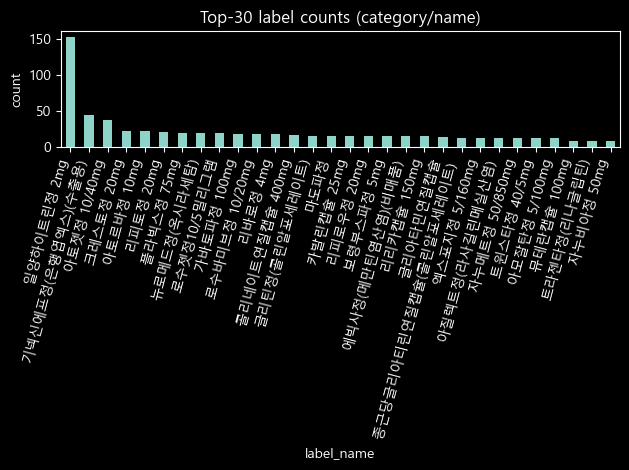

In [35]:
label_counts = df["label_name"].fillna("(None)").value_counts()
display(label_counts.head(30).to_frame("count"))

plt.figure()
label_counts.head(30).plot(kind="bar")
plt.title("Top-30 label counts (category/name)")
plt.xlabel("label_name")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 7) Shape 기반 EDA

- `drug_shape` : 알약 모양(예: 장방형 등)  
- `dl_custom_shape` : 제조 모양(복수 표현 가능)  
- `form_code_name` : 정제 분류명


,count
drug_shape,
원형,329
타원형,261
장방형,146
(None),18
팔각형,6
육각형,3


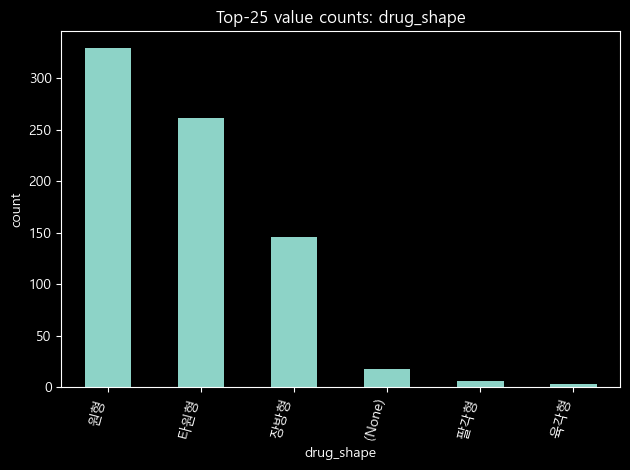

,count
dl_custom_shape,
"정제, 저작정",650
연질캡슐제,52
경질캡슐제,40
서방형정제,15
장용정제,6


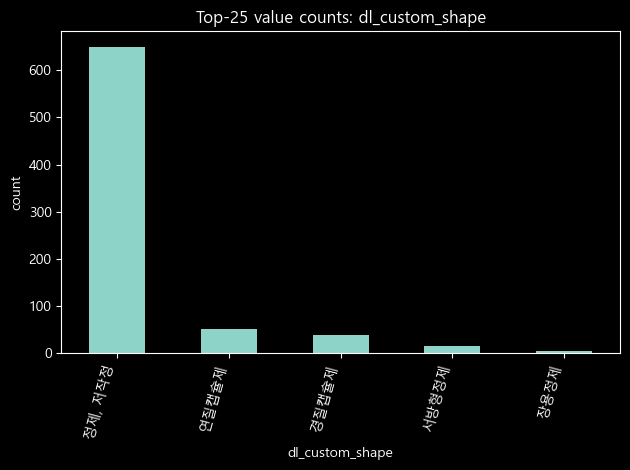

,count
form_code_name,
필름코팅정,392
나정,231
"연질캡슐제, 액상",52
"경질캡슐제, 산제",40
(None),18
서방성필름코팅정,12
다층정,12
장용성필름코팅정,6


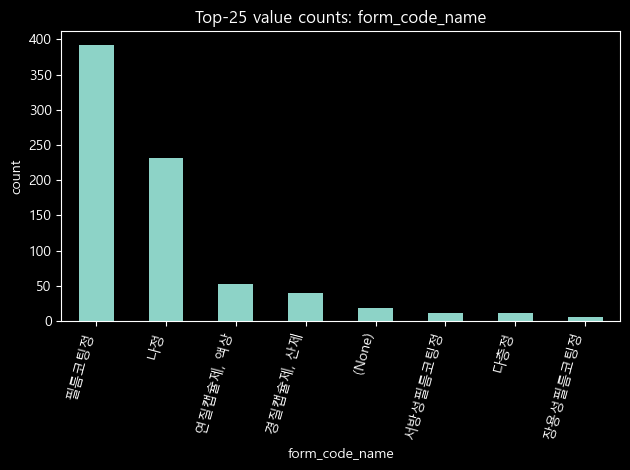

,count
color_class1,
하양,211
주황,190
분홍,119
노랑,98
갈색,56
초록,54
(None),18
"노랑, 투명",8
연두,6


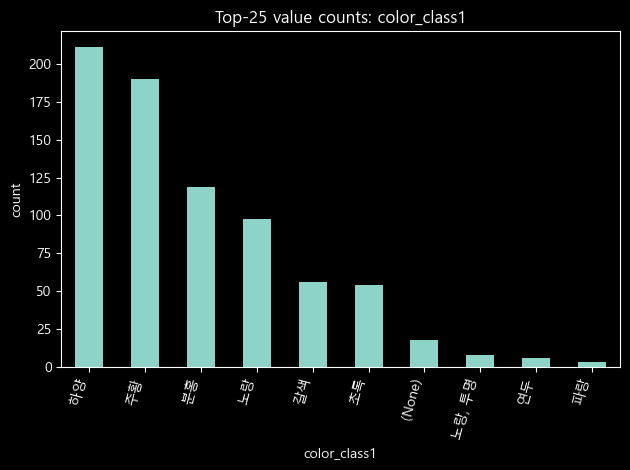

,count
color_class2,
,693
하양,31
(None),18
파랑,12
초록,9


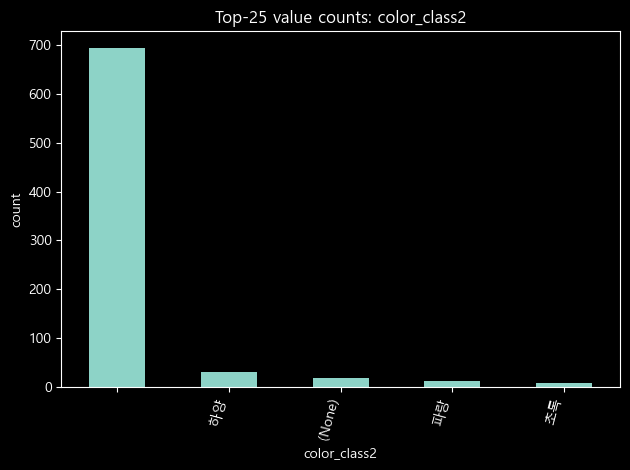

,count
line_front,
,552
-,177
(None),18
+,16


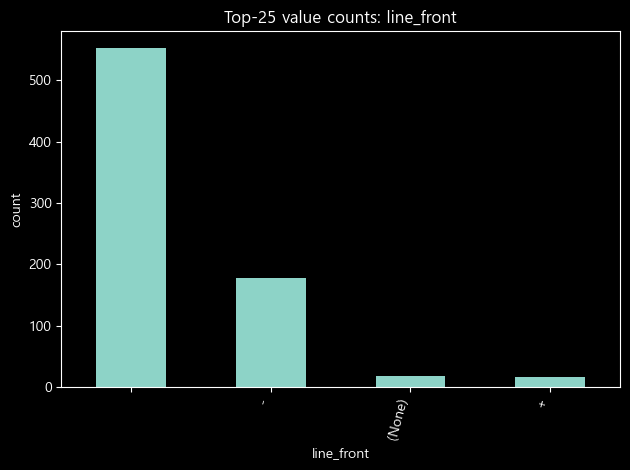

,count
line_back,
,630
-,99
(None),18
+,16


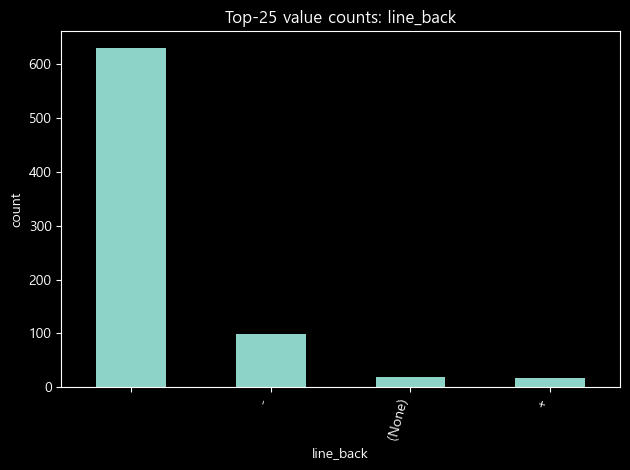

In [36]:
def plot_value_counts(col, topk=20):
    vc = df[col].fillna("(None)").value_counts().head(topk)
    display(vc.to_frame("count"))
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Top-{topk} value counts: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

for col in ["drug_shape","dl_custom_shape","form_code_name","color_class1","color_class2","line_front","line_back"]:
    plot_value_counts(col, topk=25)


drug_shape,원형,장방형,타원형
label_name,,,
글리틴정(콜린알포세레이트),0.00%,0.00%,100.00%
기넥신에프정(은행엽엑스)(수출용),0.00%,100.00%,0.00%
뉴로메드정(옥시라세탐),0.00%,100.00%,0.00%
로수바미브정 10/20mg,0.00%,0.00%,100.00%
로수젯정10/5밀리그램,0.00%,0.00%,100.00%
리리카캡슐 150mg,0.00%,100.00%,0.00%
리바로정 4mg,100.00%,0.00%,0.00%
리피로우정 20mg,100.00%,0.00%,0.00%
리피토정 20mg,100.00%,0.00%,0.00%


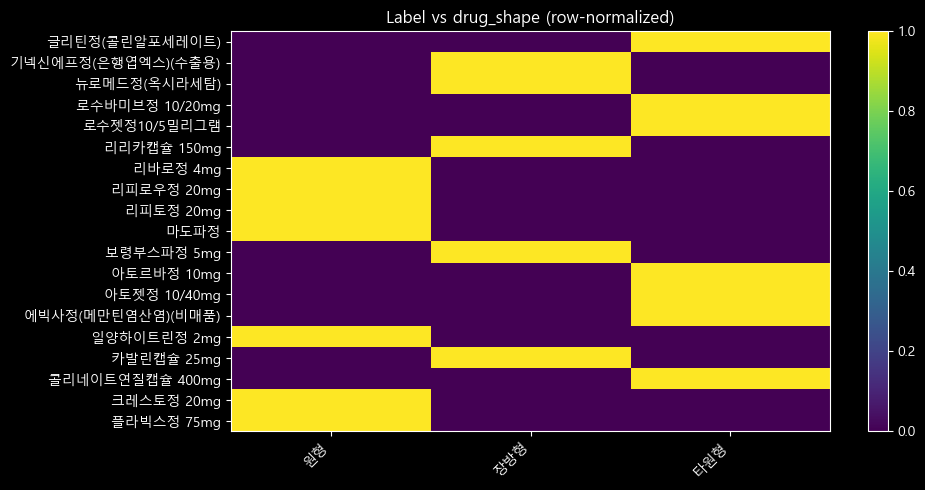

In [37]:
# shape별 라벨 분포(상위 label만) - 편향 체크
TOP_LABELS = 20
top_labels = df["label_name"].value_counts().head(TOP_LABELS).index
sub = df[df["label_name"].isin(top_labels)].copy()

ct = pd.crosstab(sub["label_name"], sub["drug_shape"], normalize="index")
display(ct.style.format("{:.2%}"))

plt.figure(figsize=(10, 5))
plt.imshow(ct.values, aspect="auto")
plt.title("Label vs drug_shape (row-normalized)")
plt.yticks(range(len(ct.index)), ct.index)
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.colorbar()
plt.tight_layout()
plt.show()


## 8) 품목(item_seq) 기준 EDA

- `item_seq`(품목기준코드) 단위로 이미지/라벨/shape 분포를 확인.
- 분류 타깃을 “품목”으로 바꾸고 싶으면 `item_seq` 또는 `dl_idx`를 라벨로 쓰는 방식이 유용.


,count
item_seq,
199101125,153
199102014,45
201500365,37
200410326,23
200705992,22
200410085,21
200700907,20
199201807,20
201503658,19


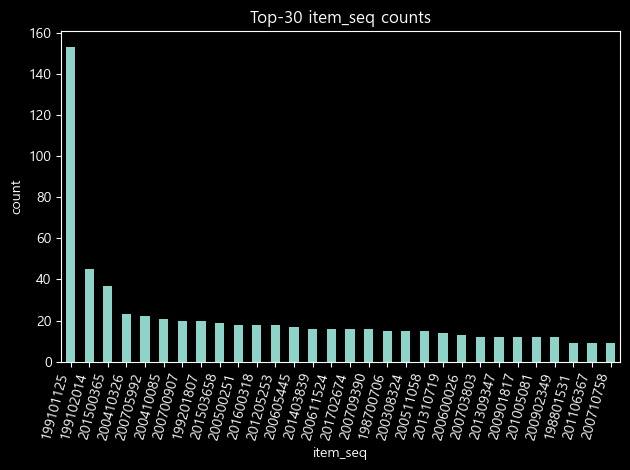

In [38]:
# item_seq 분포
item_counts = df["item_seq"].fillna("(None)").value_counts()
display(item_counts.head(30).to_frame("count"))

plt.figure()
item_counts.head(30).plot(kind="bar")
plt.title("Top-30 item_seq counts")
plt.xlabel("item_seq")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


In [39]:
# item_seq별 대표 제품명/회사/라벨 확인 (상위 item만)
TOP_ITEMS = 20
top_items = df["item_seq"].value_counts().head(TOP_ITEMS).index
item_summary = (df[df["item_seq"].isin(top_items)]
                .groupby("item_seq")
                .agg(
                    n_images=("file_name","count"),
                    n_labels=("label_name", lambda x: x.nunique(dropna=True)),
                    sample_label=("label_name", lambda x: x.dropna().iloc[0] if len(x.dropna()) else None),
                    sample_name=("dl_name", lambda x: x.dropna().iloc[0] if len(x.dropna()) else None),
                    sample_company=("dl_company", lambda x: x.dropna().iloc[0] if len(x.dropna()) else None),
                    sample_shape=("drug_shape", lambda x: x.dropna().iloc[0] if len(x.dropna()) else None),
                )
                .sort_values("n_images", ascending=False)
               )

display(item_summary)


,n_images,n_labels,sample_label,sample_name,sample_company,sample_shape
item_seq,,,,,,
199101125,153,1,일양하이트린정 2mg,일양하이트린정 2mg,일양약품(주),원형
199102014,45,1,기넥신에프정(은행엽엑스)(수출용),기넥신에프정(은행엽엑스)(수출용),에스케이케미칼(주),장방형
201500365,37,1,아토젯정 10/40mg,아토젯정 10/40mg,한국엠에스디(주),타원형
200410326,23,1,크레스토정 20mg,크레스토정 20mg,한국아스트라제네카(주),원형
200705992,22,1,아토르바정 10mg,아토르바정 10mg,(주)유한양행,타원형
200410085,21,1,리피토정 20mg,리피토정 20mg,한국화이자제약(주),원형
200700907,20,1,플라빅스정 75mg,플라빅스정 75mg,(주)한독,원형
199201807,20,1,뉴로메드정(옥시라세탐),뉴로메드정(옥시라세탐),고려제약(주),장방형
201503658,19,1,로수젯정10/5밀리그램,로수젯정10/5밀리그램,한미약품(주),타원형


drug_shape,원형,장방형,타원형
item_seq,,,
199101125,100.00%,0.00%,0.00%
199102014,0.00%,100.00%,0.00%
199201807,0.00%,100.00%,0.00%
200410085,100.00%,0.00%,0.00%
200410326,100.00%,0.00%,0.00%
200605445,0.00%,0.00%,100.00%
200611524,100.00%,0.00%,0.00%
200700907,100.00%,0.00%,0.00%
200705992,0.00%,0.00%,100.00%


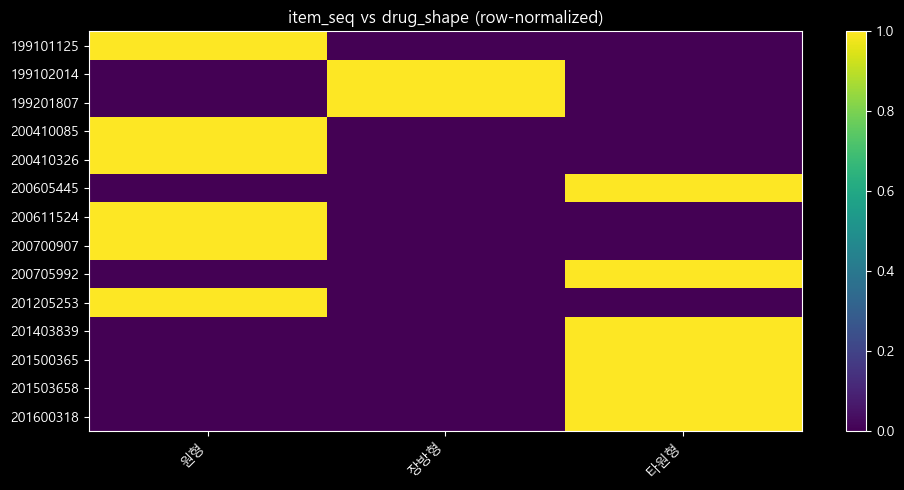

In [40]:
# item_seq vs drug_shape (row-normalized) 상위 item만
top_items = df["item_seq"].value_counts().head(15).index
sub = df[df["item_seq"].isin(top_items)].copy()
ct = pd.crosstab(sub["item_seq"], sub["drug_shape"], normalize="index")
display(ct.style.format("{:.2%}"))

plt.figure(figsize=(10, 5))
plt.imshow(ct.values, aspect="auto")
plt.title("item_seq vs drug_shape (row-normalized)")
plt.yticks(range(len(ct.index)), ct.index)
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.colorbar()
plt.tight_layout()
plt.show()


## 9) BBox 통계 (유효 bbox만)

`bbox = [x, y, w, h]` 기준으로 면적/상대면적/종횡비 확인.


In [41]:
# object 단위 테이블 생성 (valid bbox만 들어있음)
obj_rows = []
for _, r in df.iterrows():
    bboxes = r.get("bboxes", [])
    if not isinstance(bboxes, list):
        continue
    for bb in bboxes:
        if not (isinstance(bb, list) and len(bb) == 4):
            continue
        x, y, w, h = bb
        area = w*h if (w is not None and h is not None) else None
        img_w, img_h = r.get("width"), r.get("height")
        rel_area = (area/(img_w*img_h)) if (area is not None and img_w and img_h) else None
        aspect = (w/h) if (w is not None and h not in (None, 0)) else None

        obj_rows.append({
            "file_name": r.get("file_name"),
            "image_id": r.get("image_id"),
            "label_name": r.get("label_name"),
            "item_seq": r.get("item_seq"),
            "drug_shape": r.get("drug_shape"),
            "x": x, "y": y, "w": w, "h": h,
            "area": area,
            "rel_area": rel_area,
            "aspect": aspect,
        })

obj_df = pd.DataFrame(obj_rows)
print("objects(valid bbox):", len(obj_df))
obj_df.head()


objects(valid bbox): 763


,file_name,image_id,label_name,item_seq,drug_shape,x,y,w,h,area,rel_area,aspect
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,보령부스파정 5mg,198700706,장방형,644,845,189,190,35910,0.028745,0.994737
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,보령부스파정 5mg,198700706,장방형,148,241,181,181,32761,0.026224,1.000000
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,보령부스파정 5mg,198700706,장방형,167,248,184,182,33488,0.026806,1.010989
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,가바토파정 100mg,200500251,None,144,799,239,239,57121,0.045723,1.000000
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,가바토파정 100mg,200500251,None,578,222,233,226,52658,0.042151,1.030973


## 9-1) Detection QC (bbox 품질 진단: 음수/0면적/범위초과/결측)

검출 성능에 직접 영향을 주는 bbox 품질을 점검.
- `neg_coord`: x 또는 y가 음수
- `nonpos_wh`: w<=0 또는 h<=0 (면적 0 포함)
- `oob`: 이미지 경계 밖 (x<0, y<0, x+w>W, y+h>H)
- `nan_inf`: 값 결측/형변환 실패 등


In [42]:
# =========================
# Detection QC: bbox 진단 리포트 + 문제 bbox 리스트
# =========================

def bbox_qc_flags(row):
    x, y, w, h = row["x"], row["y"], row["w"], row["h"]
    W, H = row.get("img_w"), row.get("img_h")

    flags = {
        "neg_coord": False,
        "nonpos_wh": False,
        "oob": False,
        "nan_inf": False,
    }

    vals = [x, y, w, h, W, H]
    if any(v is None for v in vals):
        flags["nan_inf"] = True
        return flags

    try:
        x, y, w, h = float(x), float(y), float(w), float(h)
        W, H = float(W), float(H)
    except Exception:
        flags["nan_inf"] = True
        return flags

    if x < 0 or y < 0:
        flags["neg_coord"] = True
    if w <= 0 or h <= 0:
        flags["nonpos_wh"] = True
    if (x < 0) or (y < 0) or (x + w > W) or (y + h > H):
        flags["oob"] = True

    return flags


# obj_df에 이미지 크기 붙이기(없으면 merge)
if "img_w" not in obj_df.columns or "img_h" not in obj_df.columns:
    img_wh = df[["file_name", "width", "height"]].rename(columns={"width":"img_w","height":"img_h"})
    obj_df = obj_df.merge(img_wh, on="file_name", how="left")

flag_df = obj_df.apply(bbox_qc_flags, axis=1, result_type="expand")
obj_df_qc = pd.concat([obj_df, flag_df], axis=1)

qc_summary = obj_df_qc[["neg_coord","nonpos_wh","oob","nan_inf"]].mean().to_frame("ratio")
qc_summary["count"] = obj_df_qc[["neg_coord","nonpos_wh","oob","nan_inf"]].sum().astype(int)
display(qc_summary)

bad_bbox = obj_df_qc[obj_df_qc[["neg_coord","nonpos_wh","oob","nan_inf"]].any(axis=1)].copy()
print("bad_bbox objects:", len(bad_bbox))
display(bad_bbox.head(50))


,ratio,count
neg_coord,0.000000,0
nonpos_wh,0.000000,0
oob,0.001167,3
nan_inf,0.000000,0


bad_bbox objects: 3


,file_name,image_id,label_name,item_seq,drug_shape,x,y,w,h,area,rel_area,aspect,img_w,img_h,neg_coord,nonpos_wh,oob,nan_inf
809,K-003351-016262-018357_0_2_0_2_75_000_200.png,239,종근당글리아티린연질캡슐(콜린알포세레이트),200600026,타원형,6567,625,311,315,97965,0.078417,0.987302,976,1280,False,False,True,False
810,K-003351-016262-018357_0_2_0_2_75_000_200.png,239,종근당글리아티린연질캡슐(콜린알포세레이트),200600026,타원형,6567,625,311,315,97965,0.078417,0.987302,976,1280,False,False,True,False
811,K-003351-016262-018357_0_2_0_2_75_000_200.png,239,종근당글리아티린연질캡슐(콜린알포세레이트),200600026,타원형,6567,625,311,315,97965,0.078417,0.987302,976,1280,False,False,True,False


## 9-2) 객체 수 분포 (제한 없이 확인)

이미지마다 유효 bbox 객체(`n_ann_bbox_valid`)가 몇 개인지 분포를 확인.

,count,mean,std,min,25%,50%,75%,max
n_ann_bbox_valid,763.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


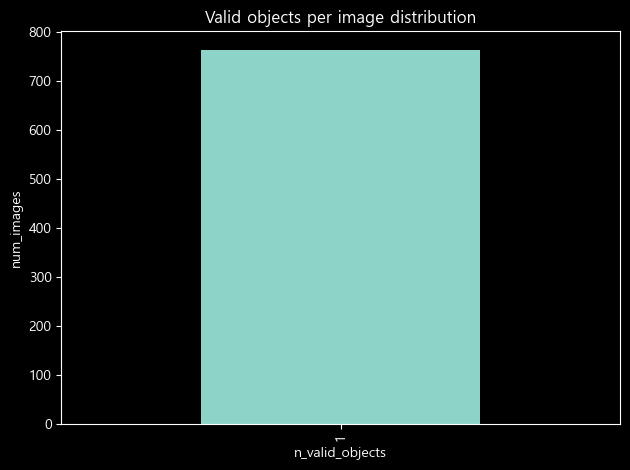

,file_name,json_path,n_ann_bbox_valid,label_name,item_seq,drug_shape
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,data\train_annotations\K-001900-016548-019607-...,1,보령부스파정 5mg,198700706,장방형
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,data\train_annotations\K-001900-016548-019607-...,1,보령부스파정 5mg,198700706,장방형
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,data\train_annotations\K-001900-016548-019607-...,1,보령부스파정 5mg,198700706,장방형
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,data\train_annotations\K-001900-016548-019607-...,1,가바토파정 100mg,200500251,None
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,data\train_annotations\K-001900-016548-019607-...,1,가바토파정 100mg,200500251,None
5,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,data\train_annotations\K-001900-016548-019607-...,1,가바토파정 100mg,200500251,None
6,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,data\train_annotations\K-001900-016548-019607-...,1,스토가정 10mg,200607849,원형
7,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,data\train_annotations\K-001900-016548-019607-...,1,스토가정 10mg,200607849,원형
8,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,data\train_annotations\K-001900-016548-019607-...,1,스토가정 10mg,200607849,원형
9,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,data\train_annotations\K-001900-016548-019607-...,1,레일라정,201201587,타원형


In [43]:
# =========================
# Image당 객체 수 분포 (제한 없이 진단)
# =========================
obj_per_image = df["n_ann_bbox_valid"].fillna(0).astype(int)

display(obj_per_image.describe().to_frame().T)

plt.figure()
obj_per_image.value_counts().sort_index().plot(kind="bar")
plt.title("Valid objects per image distribution")
plt.xlabel("n_valid_objects")
plt.ylabel("num_images")
plt.tight_layout()
plt.show()

# 상위 객체 수 샘플(많은 순)
display(df.sort_values("n_ann_bbox_valid", ascending=False)[
    ["file_name","json_path","n_ann_bbox_valid","label_name","item_seq","drug_shape"]
].head(50))


## 9-3) 객체 기준 클래스 분포 & 작은 객체(스케일) 진단

- 이미지 단위가 아니라 **객체 단위**로 클래스 분포를 확인.
- 클래스별 bbox 상대면적(`rel_area`) 통계를 통해 **작은 객체 위주 클래스**를 찾아보기.


,obj_count
label_name,
일양하이트린정 2mg,456
기넥신에프정(은행엽엑스)(수출용),180
아토젯정 10/40mg,128
크레스토정 20mg,75
리피토정 20mg,72
가바토파정 100mg,71
플라빅스정 75mg,66
아토르바정 10mg,64
뉴로메드정(옥시라세탐),60


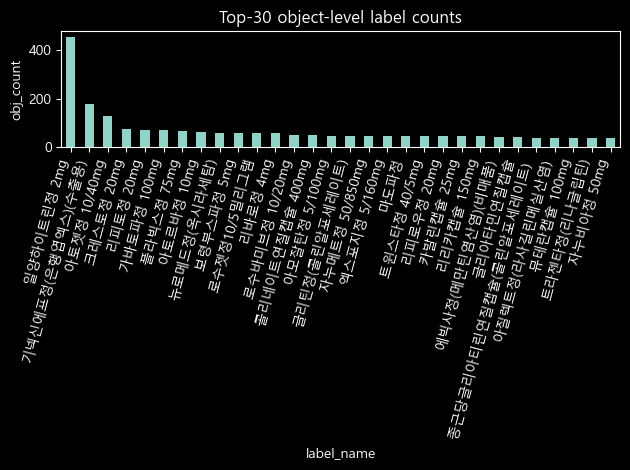

,n_obj,rel_area_mean,rel_area_p10,rel_area_p50,rel_area_p90
label_name,,,,,
일양하이트린정 2mg,456,0.027964,0.026660,0.027692,0.029507
기넥신에프정(은행엽엑스)(수출용),180,0.044600,0.041463,0.044835,0.047683
아토젯정 10/40mg,128,0.080129,0.069169,0.079672,0.092746
크레스토정 20mg,75,0.047045,0.043767,0.046877,0.049824
리피토정 20mg,72,0.029175,0.027500,0.029349,0.030898
가바토파정 100mg,71,0.044441,0.040884,0.043254,0.046103
플라빅스정 75mg,66,0.040115,0.037851,0.041060,0.042527
아토르바정 10mg,64,0.031304,0.029056,0.031634,0.033023
보령부스파정 5mg,60,0.023243,0.020128,0.022126,0.027805


,n_obj,rel_area_mean,rel_area_p10,rel_area_p50,rel_area_p90
label_name,,,,,
스토가정 10mg,24,0.019586,0.018611,0.019665,0.020615
보령부스파정 5mg,60,0.023243,0.020128,0.022126,0.027805
아빌리파이정 10mg,11,0.026856,0.026211,0.026627,0.027673
일양하이트린정 2mg,456,0.027964,0.026660,0.027692,0.029507
카나브정 60mg,12,0.028295,0.027613,0.027736,0.029537
라비에트정 20mg,12,0.028540,0.027528,0.028590,0.029501
리피로우정 20mg,47,0.028429,0.027483,0.028590,0.029501
리피토정 20mg,72,0.029175,0.027500,0.029349,0.030898
노바스크정 5mg,24,0.030665,0.029543,0.030064,0.032303


In [44]:
# =========================
# Object-level class balance & small-object diagnosis
# =========================
use_obj = obj_df_qc if "obj_df_qc" in globals() else obj_df.copy()

# rel_area 계산 보강
if "rel_area" not in use_obj.columns:
    use_obj["rel_area"] = (use_obj["area"] / (use_obj["img_w"] * use_obj["img_h"]))

obj_label_counts = use_obj["label_name"].fillna("(None)").value_counts()
display(obj_label_counts.head(30).to_frame("obj_count"))

plt.figure()
obj_label_counts.head(30).plot(kind="bar")
plt.title("Top-30 object-level label counts")
plt.xlabel("label_name")
plt.ylabel("obj_count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

by_cls = (use_obj.groupby("label_name")
          .agg(n_obj=("file_name","count"),
               rel_area_mean=("rel_area","mean"),
               rel_area_p10=("rel_area", lambda x: np.nanpercentile(x, 10)),
               rel_area_p50=("rel_area", lambda x: np.nanpercentile(x, 50)),
               rel_area_p90=("rel_area", lambda x: np.nanpercentile(x, 90)))
          .sort_values("n_obj", ascending=False)
         )
display(by_cls.head(60))

small_cls = by_cls.sort_values("rel_area_p50").head(30)
display(small_cls)


,count,mean,std,min,25%,50%,75%,max
w,2571.0,252.295605,74.268268,125.000000,190.000000,231.000000,289.000000,529.000000
h,2571.0,267.583042,97.104230,126.000000,192.000000,228.000000,323.000000,664.000000
area,2571.0,71428.141968,42992.851294,23250.000000,37050.000000,54288.000000,94550.000000,272435.000000
rel_area,2571.0,0.057175,0.034414,0.018611,0.029657,0.043455,0.075684,0.218074
aspect,2571.0,0.996959,0.276387,0.396084,0.825000,1.003953,1.049505,2.108374


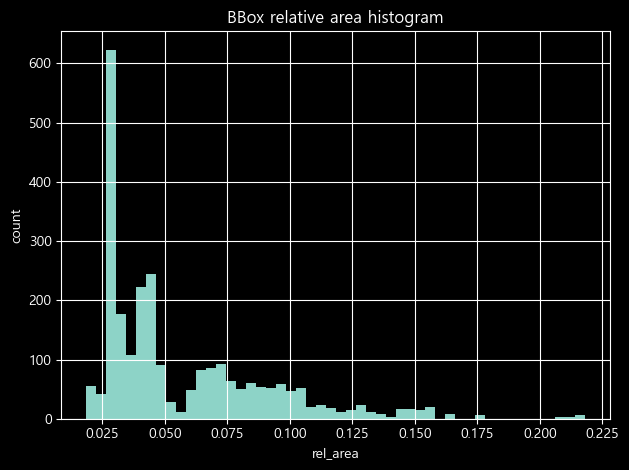

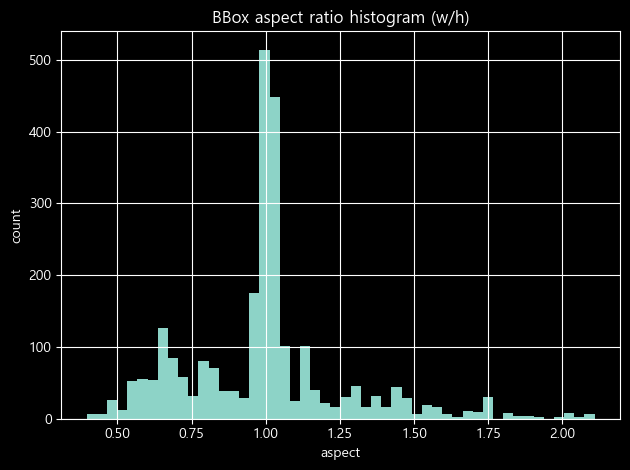

In [45]:
if len(obj_df) > 0:
    display(obj_df[["w","h","area","rel_area","aspect"]].describe().T)

    plt.figure()
    obj_df["rel_area"].dropna().hist(bins=50)
    plt.title("BBox relative area histogram")
    plt.xlabel("rel_area")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    plt.figure()
    obj_df["aspect"].dropna().hist(bins=50)
    plt.title("BBox aspect ratio histogram (w/h)")
    plt.xlabel("aspect")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No valid bbox found.")


## 10) (옵션) 특정 shape / 품목 샘플 확인

- `IMG_ROOT`를 지정하면 실제 이미지까지 띄울 수 있음.


In [46]:
import random

def show_samples_by_filter(filter_expr, n=9, seed=42):
    sub = df.query(filter_expr).copy()
    print("matched:", len(sub))
    if len(sub) == 0:
        return
    sample = sub.sample(min(n, len(sub)), random_state=seed)

    if IMG_ROOT is None:
        display(sample[["file_name","json_path","label_name","item_seq","drug_shape","dl_custom_shape","form_code_name","n_ann_bbox_valid"]])
        return

    from PIL import Image
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*3.5, rows*3.5))
    for i, (_, r) in enumerate(sample.iterrows(), start=1):
        fp = Path(IMG_ROOT) / r["file_name"]
        ax = plt.subplot(rows, cols, i)
        if fp.exists():
            ax.imshow(Image.open(fp).convert("RGB"))
        ax.set_title(str(r["file_name"]))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

matched: 146


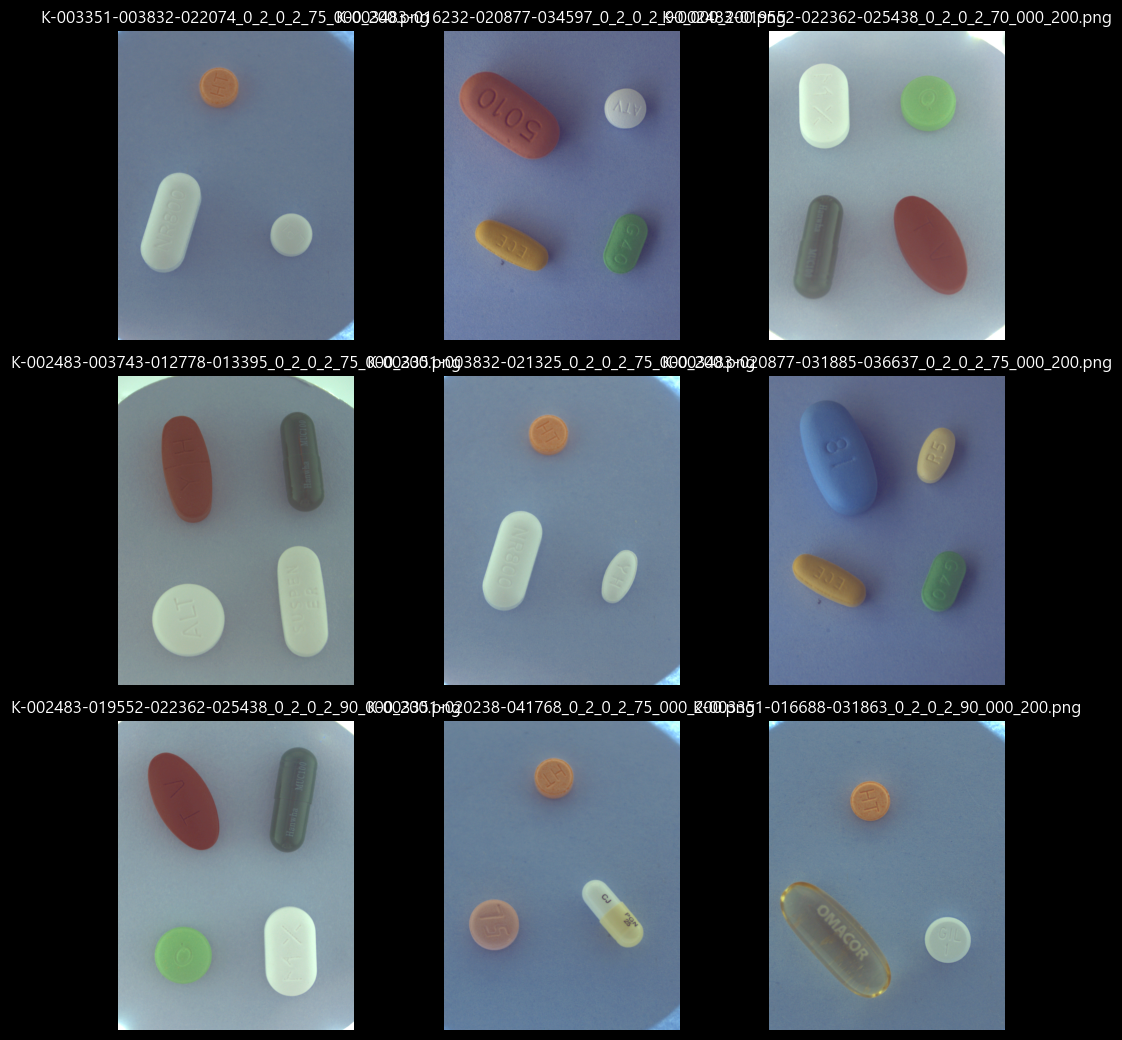

In [47]:
# 예시:
show_samples_by_filter('drug_shape == "장방형"', n=9)

matched: 15


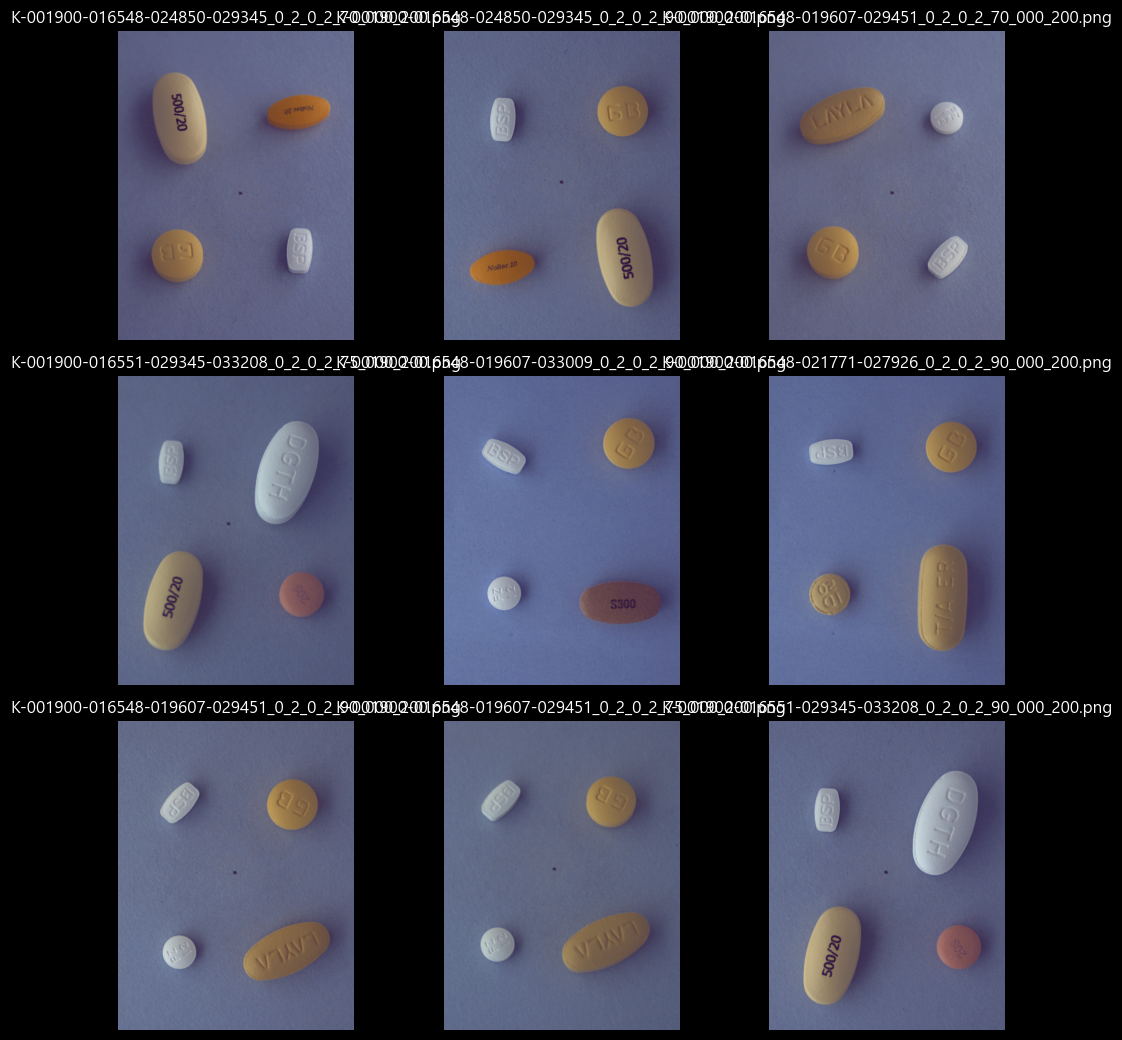

In [48]:
show_samples_by_filter('item_seq == 198700706', n=9)

## 11) 결과 저장 (CSV)

- `images_level.csv` : 이미지 단위 레코드(라벨/메타/shape/품목 포함)  
- `objects_level.csv` : 유효 bbox 객체 단위 레코드


In [49]:
OUT_DIR = Path("./eda_outputs_taeho")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT_DIR / "images_level_v2_shape_item.csv", index=False, encoding="utf-8-sig")
obj_df.to_csv(OUT_DIR / "objects_level_v2_shape_item.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print(" -", (OUT_DIR / "images_level_v2_shape_item.csv").resolve())
print(" -", (OUT_DIR / "objects_level_v2_shape_item.csv").resolve())

# (추가) QC 결과 저장
if "obj_df_qc" in globals():
    obj_df_qc.to_csv(OUT_DIR / "objects_level_v3_with_qc.csv", index=False, encoding="utf-8-sig")
    print(" -", (OUT_DIR / "objects_level_v3_with_qc.csv").resolve())


Saved:
 - C:\Users\TAEHO\Desktop\AI_07_basic\eda_outputs_taeho\images_level_v2_shape_item.csv
 - C:\Users\TAEHO\Desktop\AI_07_basic\eda_outputs_taeho\objects_level_v2_shape_item.csv
 - C:\Users\TAEHO\Desktop\AI_07_basic\eda_outputs_taeho\objects_level_v3_with_qc.csv


## 12) 모든 라벨 컬럼에 대한 자동 EDA

기존에 시각화된 라벨 외에도, **모델 학습·품질 진단에 의미가 있는 모든 라벨성 컬럼**을
동일한 기준으로 자동 EDA합니다.

- 결측률
- 유니크 값 수
- Top-K 분포



[AUTO EDA] column = drug_N
Total: 763 | Null: 0 (0.00%) | Unique: 56


,count
drug_N,
K-003351,153
K-003483,45
K-035206,37
K-016262,23
K-021325,22
K-016232,21
K-020238,20
K-003832,20
K-036637,19


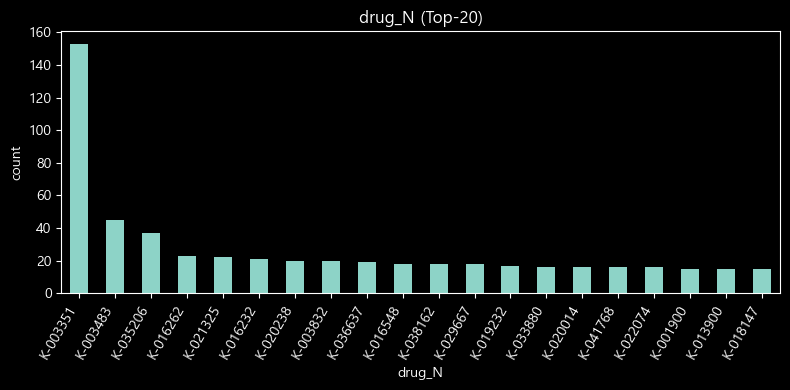


[AUTO EDA] column = drug_S
Total: 763 | Null: 0 (0.00%) | Unique: 1


,count
drug_S,
정상알약,763



[AUTO EDA] column = dl_material
Total: 763 | Null: 0 (0.00%) | Unique: 50


,count
dl_material,
테라조신염산염수화물,153
콜린알포세레이트,60
은행엽건조엑스,45
에제티미브|아토르바스타틴칼슘삼수화물,37
로수바스타틴칼슘|에제티미브,37
프레가발린,31
로수바스타틴칼슘,23
아토르바스타틴칼슘,22
아토르바스타틴칼슘삼수화물,21


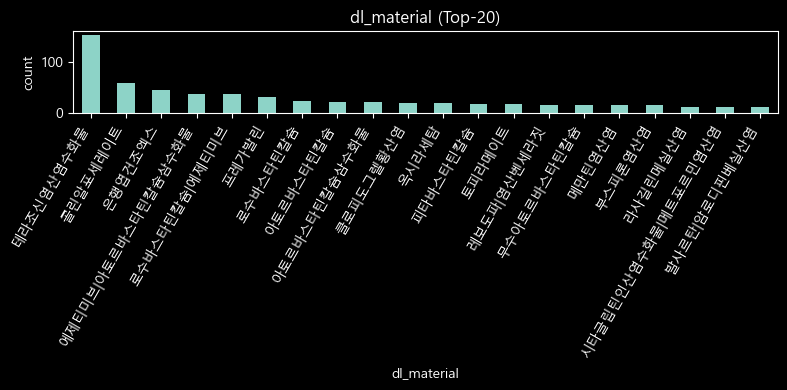

[SKIP] color_class1 (dtype not supported)
[SKIP] color_class2 (dtype not supported)
[SKIP] line_front (dtype not supported)
[SKIP] line_back (dtype not supported)
[SKIP] print_front (dtype not supported)
[SKIP] print_back (dtype not supported)
[SKIP] mark_code_front (not found)
[SKIP] mark_code_back (not found)


In [50]:
# =========================
# All-label automatic EDA (중복 최소화 버전)
# - 이미 앞에서 상세 EDA한 컬럼은 제외해서 중복을 줄입니다.
# =========================
from pandas.api.types import is_string_dtype, is_numeric_dtype

# (1) "이미 앞 섹션에서 충분히 EDA한 컬럼" 목록
EDA_DONE_COLS = {
    # 핵심 타깃/분포
    "label_name","label_cid","item_seq","dl_idx",
    # shape
    "drug_shape","dl_custom_shape","form_code_name",
    # 촬영 조건
    "back_color","light_color","drug_dir","size",
    # 기타 자주 보는 컬럼
    "dl_name","dl_company","di_class_no","di_etc_otc_code",
}

# (2) 자동 EDA 후보(필요하면 여기만 수정)
LABEL_COLUMNS_ALL = [
    # 분류/식별
    "label_name","label_cid","dl_idx","item_seq","drug_N","drug_S",

    # 제품/품목
    "dl_name","dl_company","dl_material","di_class_no","di_etc_otc_code",

    # Shape / 외형
    "drug_shape","dl_custom_shape","form_code_name",
    "color_class1","color_class2","line_front","line_back",

    # 촬영/환경
    "back_color","light_color","drug_dir","size",

    # 텍스트/마크
    "print_front","print_back","mark_code_front","mark_code_back",
]

def auto_label_eda(df, col, topk=20):
    print(f"\n{'='*90}")
    print(f"[AUTO EDA] column = {col}")
    print(f"{'='*90}")

    s = df[col]
    n_total = len(s)
    n_null = s.isna().sum()
    n_unique = s.nunique(dropna=True)

    print(f"Total: {n_total} | Null: {n_null} ({n_null/n_total:.2%}) | Unique: {n_unique}")

    vc = s.fillna("(None)").value_counts()
    display(vc.head(topk).to_frame("count"))

    if vc.shape[0] > 1:
        plt.figure(figsize=(8, 4))
        vc.head(topk).plot(kind="bar")
        plt.title(f"{col} (Top-{topk})")
        plt.ylabel("count")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()

for col in LABEL_COLUMNS_ALL:
    if col not in df.columns:
        print(f"[SKIP] {col} (not found)")
        continue

    # ✅ 중복 방지: 앞에서 이미 다룬 컬럼은 건너뜀
    if col in EDA_DONE_COLS:
        continue

    if is_string_dtype(df[col]) or is_numeric_dtype(df[col]):
        auto_label_eda(df, col, topk=20)
    else:
        print(f"[SKIP] {col} (dtype not supported)")


## 13) 라벨 정리표 — 검출 클래스 후보 vs 보조/메타 컬럼

목표가 **알약 이름(클래스) + bbox 검출**이므로,
컬럼을 아래처럼 구분해두면 이후 학습/리포트가 깔끔해집니다.

- **Detection class candidate**: 검출 클래스(분류 타깃)로 쓸 후보  
- **Auxiliary feature**: 분석/편향 진단에 유용하지만 타깃은 아님  
- **Metadata / ID**: 관리·추적용(학습 타깃/특성으로 직접 쓰기엔 부적합한 경우가 많음)

또한 `label_name` ↔ `item_seq`/`dl_idx` 같은 **매핑 충돌(1:N, N:1)** 도 자동 체크합니다.


In [51]:
# =========================
# Q1) 라벨 정리표 + 매핑 충돌 체크
# =========================
import pandas as pd
import numpy as np

# (1) 라벨/컬럼 역할 정의(프로젝트 의도 기반)
ROLE_MAP = [
    # --- 검출 클래스 후보 ---
    {"col":"label_name", "role":"detection_class_candidate", "why":"현재 파이프라인의 대표 클래스(카테고리 명)"},
    {"col":"label_cid",  "role":"detection_class_candidate", "why":"정수형 클래스 id"},
    {"col":"dl_idx",     "role":"detection_class_candidate", "why":"제공 데이터 설명상 category_id 생성 근거(정수형으로 변환 가능)"},
    {"col":"item_seq",   "role":"detection_class_candidate", "why":"품목기준코드. 목표/정책에 따라 클래스 정의로 사용 가능"},
    {"col":"drug_N",     "role":"detection_class_candidate", "why":"알약코드. 데이터 관리/클래스 정의 후보"},

    # --- 보조/편향 진단(학습 타깃은 아님) ---
    {"col":"drug_shape",     "role":"auxiliary_feature", "why":"모양 편향/난이도 분석"},
    {"col":"dl_custom_shape","role":"auxiliary_feature", "why":"제조 모양(텍스트) 편향/난이도 분석"},
    {"col":"form_code_name", "role":"auxiliary_feature", "why":"정제 분류명 편향 분석"},
    {"col":"color_class1",   "role":"auxiliary_feature", "why":"색상 편향"},
    {"col":"color_class2",   "role":"auxiliary_feature", "why":"보조 색상 편향"},
    {"col":"line_front",     "role":"auxiliary_feature", "why":"분할선 유무 편향"},
    {"col":"line_back",      "role":"auxiliary_feature", "why":"분할선 유무 편향"},
    {"col":"back_color",     "role":"auxiliary_feature", "why":"배경 편향"},
    {"col":"light_color",    "role":"auxiliary_feature", "why":"조명 편향"},
    {"col":"drug_dir",       "role":"auxiliary_feature", "why":"방향 편향"},
    {"col":"size",           "role":"auxiliary_feature", "why":"스케일/해상도 편향"},
    {"col":"print_front",    "role":"auxiliary_feature", "why":"식별문자(앞) - OCR/난이도"},
    {"col":"print_back",     "role":"auxiliary_feature", "why":"식별문자(뒤) - OCR/난이도"},

    # --- 메타/ID ---
    {"col":"file_name",      "role":"metadata_or_id", "why":"파일 식별자"},
    {"col":"image_id",       "role":"metadata_or_id", "why":"이미지 고유 id"},
    {"col":"json_path",      "role":"metadata_or_id", "why":"원본 json 위치"},
    {"col":"dl_name",        "role":"metadata_or_id", "why":"제품명(표시용). 라벨과 중복 가능"},
    {"col":"dl_company",     "role":"metadata_or_id", "why":"제조사(분석용). 타깃으로 쓰면 목적과 달라짐"},
    {"col":"di_class_no",    "role":"metadata_or_id", "why":"약품 분류(규격/분류 메타)"},
    {"col":"di_etc_otc_code","role":"metadata_or_id", "why":"전문의/일반 여부(메타)"},
    {"col":"dl_material",    "role":"metadata_or_id", "why":"성분명(메타)"},
]

role_df = pd.DataFrame(ROLE_MAP)

# (2) 통계 붙이기: 결측률/유니크/Top1 점유율
stats = []
for col in role_df["col"]:
    if col not in df.columns:
        stats.append({"col":col, "null_rate":np.nan, "n_unique":np.nan, "top1_share":np.nan})
        continue
    s = df[col]
    null_rate = float(s.isna().mean())
    n_unique = int(s.nunique(dropna=True))
    vc = s.fillna("(None)").value_counts()
    top1_share = float(vc.iloc[0] / len(s)) if len(vc) else np.nan
    stats.append({"col":col, "null_rate":null_rate, "n_unique":n_unique, "top1_share":top1_share})

stats_df = pd.DataFrame(stats)

label_taxonomy = role_df.merge(stats_df, on="col", how="left")     .sort_values(["role","null_rate"], ascending=[True, False])

display(label_taxonomy)

# (3) 매핑 충돌 체크: label_name이 item_seq/dl_idx와 1:1인지
def mapping_check(a, b, _df):
    sub = _df[[a,b]].dropna()
    if len(sub)==0:
        return {"pair":f"{a} <-> {b}", "rows":0, "a_to_b_max":np.nan, "b_to_a_max":np.nan, "note":"no rows"}
    a_to_b = sub.groupby(a)[b].nunique()
    b_to_a = sub.groupby(b)[a].nunique()
    return {
        "pair":f"{a} <-> {b}",
        "rows":len(sub),
        "a_to_b_max":int(a_to_b.max()),
        "b_to_a_max":int(b_to_a.max()),
        "note":"1:1" if (a_to_b.max()==1 and b_to_a.max()==1) else "collision"
    }

pairs = [
    ("label_name","dl_idx"),
    ("label_name","item_seq"),
    ("label_name","drug_N"),
    ("dl_idx","item_seq"),
]
checks = pd.DataFrame([mapping_check(a,b,df) for a,b in pairs])
display(checks)

# 충돌 케이스 샘플 보기(상위)
for a,b in pairs:
    sub = df[[a,b,"file_name"]].dropna()
    if len(sub)==0: 
        continue
    a_to_b = sub.groupby(a)[b].nunique().sort_values(ascending=False)
    if a_to_b.iloc[0] > 1:
        bad_a = a_to_b.head(5).index.tolist()
        print(f"\n[Collision] {a} -> multiple {b}: showing samples")
        display(sub[sub[a].isin(bad_a)].head(30))


,col,role,why,null_rate,n_unique,top1_share
5,drug_shape,auxiliary_feature,모양 편향/난이도 분석,0.023591,5,0.431193
7,form_code_name,auxiliary_feature,정제 분류명 편향 분석,0.023591,7,0.513761
8,color_class1,auxiliary_feature,색상 편향,0.023591,9,0.276540
9,color_class2,auxiliary_feature,보조 색상 편향,0.023591,4,0.908257
10,line_front,auxiliary_feature,분할선 유무 편향,0.023591,3,0.723460
11,line_back,auxiliary_feature,분할선 유무 편향,0.023591,3,0.825688
16,print_front,auxiliary_feature,식별문자(앞) - OCR/난이도,0.023591,49,0.200524
17,print_back,auxiliary_feature,식별문자(뒤) - OCR/난이도,0.023591,24,0.335518
6,dl_custom_shape,auxiliary_feature,제조 모양(텍스트) 편향/난이도 분석,0.000000,5,0.851900
12,back_color,auxiliary_feature,배경 편향,0.000000,1,1.000000


,pair,rows,a_to_b_max,b_to_a_max,note
0,label_name <-> dl_idx,763,1,1,1:1
1,label_name <-> item_seq,763,1,1,1:1
2,label_name <-> drug_N,763,1,1,1:1
3,dl_idx <-> item_seq,763,1,1,1:1


## 14) 학습 전략 리포트 — EDA 지표 기반 자동 요약

EDA에서 계산한 지표를 바탕으로, 현재 데이터의 난이도 포인트와 권장 학습 설정을 요약.

- 클래스 불균형(이미지/객체 기준)
- 작은 객체 비율(rel_area)
- bbox 품질(oob/nonpos_wh 등)
- 촬영/shape 편향(필요 시)


In [52]:
# =========================
# Detection training strategy report
# =========================
from IPython.display import Markdown, display
import numpy as np
import pandas as pd

lines = []
lines.append("### 데이터 기반 학습 전략 요약")

# 1) bbox 품질
if "obj_df_qc" in globals() and len(obj_df_qc) > 0:
    qc_cols = ["neg_coord","nonpos_wh","oob","nan_inf"]
    qc_ratio = obj_df_qc[qc_cols].mean()
    lines.append("\n**1) bbox 품질(QC)**")
    lines.append(f"- oob(경계초과) 비율: **{qc_ratio['oob']:.2%}**")
    lines.append(f"- nonpos_wh(0/음수 면적) 비율: **{qc_ratio['nonpos_wh']:.2%}**")
    lines.append(f"- neg_coord(음수 좌표) 비율: **{qc_ratio['neg_coord']:.2%}**")

    if qc_ratio["oob"] > 0.01:
        lines.append("  - 권장: 학습 전 **클리핑(이미지 경계로 자르기)** 또는 **해당 샘플 제외** 정책을 명확히 하세요.")
    if qc_ratio["nonpos_wh"] > 0:
        lines.append("  - 권장: 0/음수 면적 bbox는 **학습에서 제외**(loss/anchor 매칭에 치명적).")
else:
    lines.append("\n**1) bbox 품질(QC)**")
    lines.append("- obj_df_qc가 없거나 객체가 없어 QC 요약을 생략했습니다.")

# 2) 객체 수 분포
lines.append("\n**2) 이미지당 객체 수 분포**")
obj_per_image = df["n_ann_bbox_valid"].fillna(0).astype(int)
lines.append(f"- 평균: **{obj_per_image.mean():.2f}**, 중앙값: **{obj_per_image.median():.0f}**, 최대: **{obj_per_image.max():.0f}**")
if obj_per_image.max() >= 6:
    lines.append("  - 권장: 학습/추론 모두 **NMS 설정**(IoU threshold)과 **max_det**를 충분히 크게 두고 시작하는 편이 안전합니다.")

# 3) 클래스 불균형(객체 기준)
lines.append("\n**3) 클래스 불균형(객체 기준)**")
if "obj_df_qc" in globals():
    use_obj = obj_df_qc
else:
    use_obj = obj_df

if len(use_obj) > 0:
    vc = use_obj["label_name"].fillna("(None)").value_counts()
    top1 = vc.iloc[0]
    top1_share = top1 / vc.sum()
    tail_share = vc[vc <= 5].sum() / vc.sum()  # 희귀 클래스(<=5개 객체) 비율
    lines.append(f"- Top-1 클래스 점유율(객체): **{top1_share:.2%}**")
    lines.append(f"- 희귀 클래스(객체<=5) 비율: **{tail_share:.2%}**")
    if top1_share > 0.25:
        lines.append("  - 권장: **클래스 불균형**이 큽니다. focal loss/클래스 가중치/리샘플링을 검토하세요.")
    if tail_share > 0.10:
        lines.append("  - 권장: 희귀 클래스는 성능이 급락하기 쉬우니, 평가 시 클래스별 AP를 같이 보거나, 데이터 증강을 보강하세요.")
else:
    lines.append("- 객체 테이블이 비어있어 객체 기준 불균형을 계산할 수 없습니다.")

# 4) 작은 객체 진단(rel_area)
lines.append("\n**4) 작은 객체(스케일) 진단**")
if len(use_obj) > 0:
    # rel_area 계산 보강
    if "img_w" not in use_obj.columns or "img_h" not in use_obj.columns:
        img_wh = df[["file_name", "width", "height"]].rename(columns={"width":"img_w","height":"img_h"})
        use_obj = use_obj.merge(img_wh, on="file_name", how="left")

    if "rel_area" not in use_obj.columns:
        use_obj["rel_area"] = use_obj["area"] / (use_obj["img_w"] * use_obj["img_h"])

    ra = use_obj["rel_area"].dropna()
    if len(ra):
        p10, p50 = np.nanpercentile(ra, 10), np.nanpercentile(ra, 50)
        small_rate = float((ra < 0.01).mean())  # 이미지 면적의 1% 미만
        lines.append(f"- rel_area p10: **{p10:.4f}**, p50: **{p50:.4f}**")
        lines.append(f"- 작은 객체 비율(rel_area<1%): **{small_rate:.2%}**")
        if small_rate > 0.30:
            lines.append("  - 권장: 작은 객체가 많습니다. **입력 해상도↑**, 멀티스케일/랜덤리사이즈, 작은 앵커/피처레벨(FPN) 활용이 유리합니다.")
    else:
        lines.append("- rel_area 계산 값이 없어 작은 객체 진단을 생략했습니다.")
else:
    lines.append("- 객체 테이블이 비어있어 스케일 진단을 생략했습니다.")

# 5) 촬영/shape 편향(간단 요약)
lines.append("\n**5) 편향(촬영/shape) 힌트**")
for col in ["back_color","light_color","drug_dir","drug_shape"]:
    if col in df.columns:
        vc = df[col].fillna("(None)").value_counts()
        if len(vc) > 0:
            share = float(vc.iloc[0] / vc.sum())
            lines.append(f"- {col} top1 점유율: **{share:.2%}**")
            if share > 0.5:
                lines.append(f"  - 권장: {col} 편향이 큽니다. 학습/검증 split에서 {col} 분포가 크게 어긋나지 않게 주의하세요.")

report = "\n".join(lines)
display(Markdown(report))


### 데이터 기반 학습 전략 요약

**1) bbox 품질(QC)**
- oob(경계초과) 비율: **0.12%**
- nonpos_wh(0/음수 면적) 비율: **0.00%**
- neg_coord(음수 좌표) 비율: **0.00%**

**2) 이미지당 객체 수 분포**
- 평균: **1.00**, 중앙값: **1**, 최대: **1**

**3) 클래스 불균형(객체 기준)**
- Top-1 클래스 점유율(객체): **17.74%**
- 희귀 클래스(객체<=5) 비율: **0.00%**

**4) 작은 객체(스케일) 진단**
- rel_area p10: **0.0274**, p50: **0.0435**
- 작은 객체 비율(rel_area<1%): **0.00%**

**5) 편향(촬영/shape) 힌트**
- back_color top1 점유율: **100.00%**
  - 권장: back_color 편향이 큽니다. 학습/검증 split에서 back_color 분포가 크게 어긋나지 않게 주의하세요.
- light_color top1 점유율: **100.00%**
  - 권장: light_color 편향이 큽니다. 학습/검증 split에서 light_color 분포가 크게 어긋나지 않게 주의하세요.
- drug_dir top1 점유율: **98.43%**
  - 권장: drug_dir 편향이 큽니다. 학습/검증 split에서 drug_dir 분포가 크게 어긋나지 않게 주의하세요.
- drug_shape top1 점유율: **43.12%**